In [1]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive.zip


In [2]:
import zipfile
import os

with zipfile.ZipFile('archive.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

print("Extracted successfully!")
print(os.listdir('data/food-101-tiny/train'))

Extracted successfully!
['tiramisu', 'edamame', 'falafel', 'sushi', 'ice_cream', 'apple_pie', 'french_toast', 'bibimbap', 'ramen', 'cannoli']


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder
from skimage.feature import hog
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
# Calorie information per 100g serving (approximate values)
calorie_info = {
    'apple_pie': 237,
    'bibimbap': 121,
    'cannoli': 296,
    'edamame': 122,
    'falafel': 333,
    'french_toast': 229,
    'ice_cream': 207,
    'ramen': 436,
    'sushi': 150,
    'tiramisu': 283
}

print("🍽️ Calorie Information (per 100g serving):")
print("="*40)
for food, cal in calorie_info.items():
    print(f"  {food:15s}: {cal} kcal")

🍽️ Calorie Information (per 100g serving):
  apple_pie      : 237 kcal
  bibimbap       : 121 kcal
  cannoli        : 296 kcal
  edamame        : 122 kcal
  falafel        : 333 kcal
  french_toast   : 229 kcal
  ice_cream      : 207 kcal
  ramen          : 436 kcal
  sushi          : 150 kcal
  tiramisu       : 283 kcal


In [5]:
dataset_path = 'data/food-101-tiny/train'
food_folders = sorted(os.listdir(dataset_path))

images = []
labels = []

print("Loading images...")
print(f"Food classes: {food_folders}")

for food in food_folders:
    food_path = os.path.join(dataset_path, food)
    if os.path.isdir(food_path):
        for filename in os.listdir(food_path):
            if filename.endswith(('.jpg', '.jpeg', '.png')):
                img_path = os.path.join(food_path, filename)
                img = cv2.imread(img_path)
                img = cv2.resize(img, (64, 64))
                img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

                images.append(img_gray)
                labels.append(food)

images = np.array(images)
labels = np.array(labels)

print(f"\nTotal images loaded: {len(images)}")

unique, counts = np.unique(labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {u}: {c} images")

Loading images...
Food classes: ['apple_pie', 'bibimbap', 'cannoli', 'edamame', 'falafel', 'french_toast', 'ice_cream', 'ramen', 'sushi', 'tiramisu']

Total images loaded: 1500
  apple_pie: 150 images
  bibimbap: 150 images
  cannoli: 150 images
  edamame: 150 images
  falafel: 150 images
  french_toast: 150 images
  ice_cream: 150 images
  ramen: 150 images
  sushi: 150 images
  tiramisu: 150 images


In [6]:
# Encode labels
label_encoder = LabelEncoder()
labels_encoded = label_encoder.fit_transform(labels)

print("Label mapping:")
for i, food in enumerate(label_encoder.classes_):
    print(f"  {i} → {food}")

# Extract HOG features
print("\nExtracting HOG features...")
hog_features = []

for img in images:
    features = hog(img,
                   orientations=9,
                   pixels_per_cell=(8, 8),
                   cells_per_block=(2, 2),
                   visualize=False)
    hog_features.append(features)

hog_features = np.array(hog_features)
print(f"\nHOG features shape: {hog_features.shape}")

Label mapping:
  0 → apple_pie
  1 → bibimbap
  2 → cannoli
  3 → edamame
  4 → falafel
  5 → french_toast
  6 → ice_cream
  7 → ramen
  8 → sushi
  9 → tiramisu

Extracting HOG features...

HOG features shape: (1500, 1764)


In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(hog_features)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, labels_encoded, test_size=0.2, random_state=42
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 1200
Testing samples: 300


In [8]:
print("Training SVM model... (this may take a minute) ⏳")

svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_model.fit(X_train, y_train)

print("SVM model trained successfully! ✅")

Training SVM model... (this may take a minute) ⏳
SVM model trained successfully! ✅


In [9]:
y_pred = svm_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"✅ Accuracy: {accuracy*100:.2f}%")
print(f"\n📊 Classification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

✅ Accuracy: 24.67%

📊 Classification Report:
              precision    recall  f1-score   support

   apple_pie       0.24      0.21      0.23        28
    bibimbap       0.18      0.32      0.23        28
     cannoli       0.25      0.12      0.16        34
     edamame       0.32      0.26      0.29        31
     falafel       0.16      0.28      0.20        25
french_toast       0.10      0.12      0.11        24
   ice_cream       0.29      0.39      0.33        28
       ramen       0.65      0.34      0.45        38
       sushi       0.41      0.18      0.25        38
    tiramisu       0.18      0.23      0.20        26

    accuracy                           0.25       300
   macro avg       0.28      0.25      0.25       300
weighted avg       0.30      0.25      0.25       300



In [10]:
print("Extracting color histogram features...")

color_features = []

for img_path_idx in range(len(images)):
    pass

# Reload images in color this time
images_color = []
for food in food_folders:
    food_path = os.path.join(dataset_path, food)
    if os.path.isdir(food_path):
        for filename in os.listdir(food_path):
            if filename.endswith(('.jpg', '.jpeg', '.png')):
                img_path = os.path.join(food_path, filename)
                img = cv2.imread(img_path)
                img = cv2.resize(img, (64, 64))
                images_color.append(img)

print(f"Color images loaded: {len(images_color)}")

Extracting color histogram features...
Color images loaded: 1500


In [11]:
print("Extracting combined HOG + Color features...")

combined_features = []

for i, img in enumerate(images_color):
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # HOG features
    hog_feat = hog(img_gray,
                   orientations=9,
                   pixels_per_cell=(8, 8),
                   cells_per_block=(2, 2),
                   visualize=False)

    # Color histogram features
    hist_b = cv2.calcHist([img], [0], None, [32], [0, 256]).flatten()
    hist_g = cv2.calcHist([img], [1], None, [32], [0, 256]).flatten()
    hist_r = cv2.calcHist([img], [2], None, [32], [0, 256]).flatten()

    color_feat = np.concatenate([hist_b, hist_g, hist_r])

    # Combine both
    combined = np.concatenate([hog_feat, color_feat])
    combined_features.append(combined)

combined_features = np.array(combined_features)
print(f"Combined features shape: {combined_features.shape}")

Extracting combined HOG + Color features...
Combined features shape: (1500, 1860)


In [12]:
scaler2 = StandardScaler()
X_scaled2 = scaler2.fit_transform(combined_features)

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_scaled2, labels_encoded, test_size=0.2, random_state=42
)

print("Training improved SVM model... ⏳")
svm_model2 = SVC(kernel='rbf', C=10.0, gamma='scale', random_state=42)
svm_model2.fit(X_train2, y_train2)

y_pred2 = svm_model2.predict(X_test2)
accuracy2 = accuracy_score(y_test2, y_pred2)

print(f"\n✅ New Accuracy: {accuracy2*100:.2f}%")
print(f"\n📊 Classification Report:")
print(classification_report(y_test2, y_pred2, target_names=label_encoder.classes_))

Training improved SVM model... ⏳

✅ New Accuracy: 31.00%

📊 Classification Report:
              precision    recall  f1-score   support

   apple_pie       0.24      0.18      0.20        28
    bibimbap       0.33      0.54      0.41        28
     cannoli       0.19      0.21      0.20        34
     edamame       0.57      0.52      0.54        31
     falafel       0.11      0.16      0.13        25
french_toast       0.20      0.21      0.20        24
   ice_cream       0.38      0.39      0.39        28
       ramen       0.68      0.39      0.50        38
       sushi       0.33      0.18      0.24        38
    tiramisu       0.22      0.31      0.26        26

    accuracy                           0.31       300
   macro avg       0.33      0.31      0.31       300
weighted avg       0.34      0.31      0.31       300



In [13]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [14]:
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# Prepare images for CNN (using color images, resized to 96x96)
images_cnn = []
labels_cnn = []

dataset_path = 'data/food-101-tiny/train'
food_folders = sorted(os.listdir(dataset_path))

for food in food_folders:
    food_path = os.path.join(dataset_path, food)
    if os.path.isdir(food_path):
        for filename in os.listdir(food_path):
            if filename.endswith(('.jpg', '.jpeg', '.png')):
                img_path = os.path.join(food_path, filename)
                img = cv2.imread(img_path)
                img = cv2.resize(img, (96, 96))
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                images_cnn.append(img)
                labels_cnn.append(food)

images_cnn = np.array(images_cnn)
labels_cnn = np.array(labels_cnn)

label_encoder_cnn = LabelEncoder()
labels_cnn_encoded = label_encoder_cnn.fit_transform(labels_cnn)
labels_cnn_categorical = to_categorical(labels_cnn_encoded)

print(f"Images shape: {images_cnn.shape}")
print(f"Labels shape: {labels_cnn_categorical.shape}")

Images shape: (1500, 96, 96, 3)
Labels shape: (1500, 10)


In [15]:
X_train_cnn, X_test_cnn, y_train_cnn, y_test_cnn = train_test_split(
    images_cnn, labels_cnn_categorical, test_size=0.2, random_state=42
)

# Preprocess for MobileNetV2
X_train_cnn = preprocess_input(X_train_cnn.astype('float32'))
X_test_cnn = preprocess_input(X_test_cnn.astype('float32'))

print(f"Training samples: {X_train_cnn.shape[0]}")
print(f"Testing samples: {X_test_cnn.shape[0]}")

Training samples: 1200
Testing samples: 300


In [16]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(96, 96, 3))
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
predictions = Dense(10, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 48, 48,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 48, 48,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 48, 48,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 48, 48,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 48, 48,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 48, 48,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 49, 49,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 24, 24,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 24, 24,    │      2,304 │ block_1_depthwis

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [17]:
print("Training CNN model... ⏳")

history = model.fit(
    X_train_cnn, y_train_cnn,
    validation_data=(X_test_cnn, y_test_cnn),
    epochs=15,
    batch_size=32,
    verbose=1
)

print("\nTraining complete! ✅")

Training CNN model... ⏳
Epoch 1/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 46s 700ms/step - accuracy: 0.5200 - loss: 1.3857 - val_accuracy: 0.6667 - val_loss: 0.9511
Epoch 2/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.8575 - loss: 0.4659 - val_accuracy: 0.6700 - val_loss: 0.8770
Epoch 3/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9492 - loss: 0.2317 - val_accuracy: 0.6867 - val_loss: 0.8908
Epoch 4/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9858 - loss: 0.1270 - val_accuracy: 0.6933 - val_loss: 0.8921
Epoch 5/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9975 - loss: 0.0731 - val_accuracy: 0.7067 - val_loss: 0.8599
Epoch 6/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 1.0000 - loss: 0.0454 - val_accuracy: 0.7233 - val_loss: 0.8351
Epoch 7/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 1.0000 - loss: 0.0304 - val_accuracy: 0.7167 - val_loss: 0.8538
Epoch 8/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 1.0000 - loss: 0.0222 

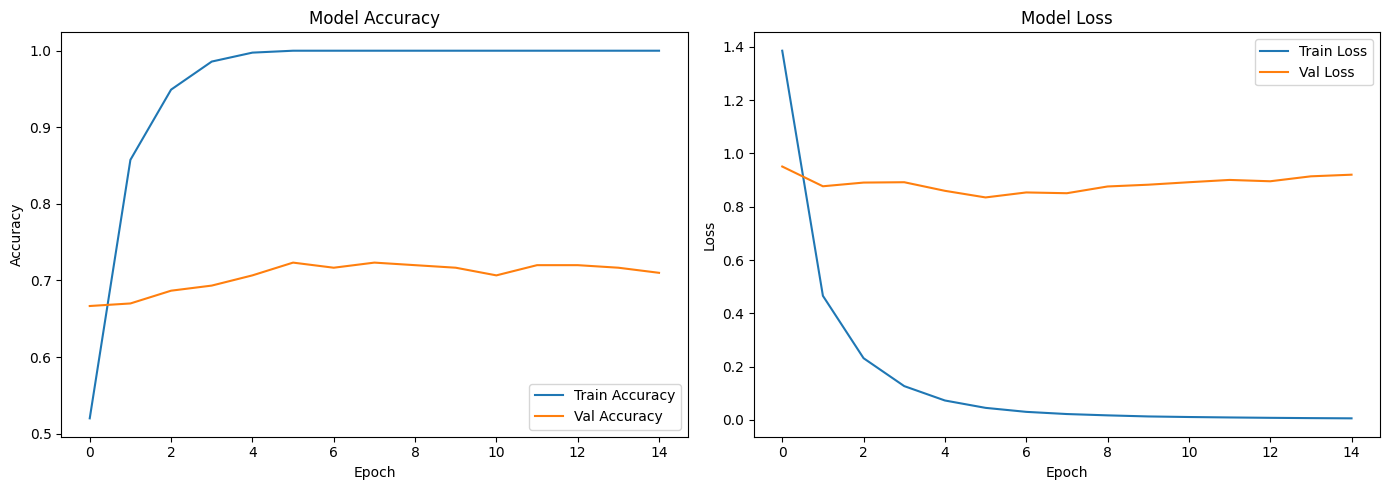

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('training_history.png')
plt.show()

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
✅ Final CNN Accuracy: 71.00%


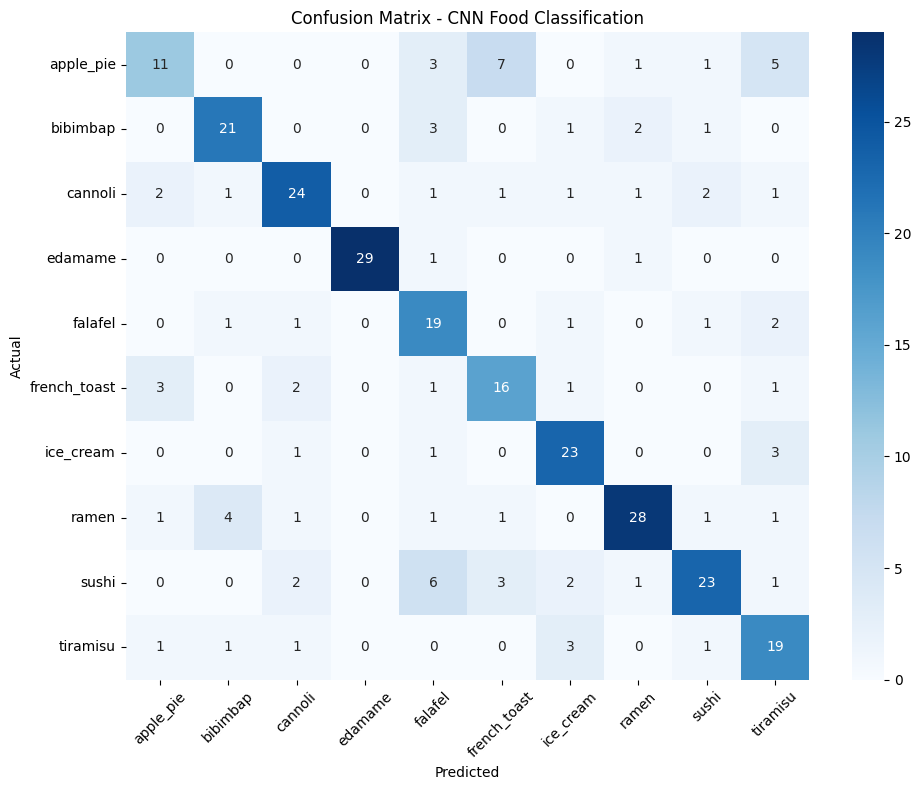

In [21]:
import seaborn as sns

y_pred_cnn = model.predict(X_test_cnn)
y_pred_classes = np.argmax(y_pred_cnn, axis=1)
y_true_classes = np.argmax(y_test_cnn, axis=1)

final_accuracy = accuracy_score(y_true_classes, y_pred_classes)
print(f"✅ Final CNN Accuracy: {final_accuracy*100:.2f}%")

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true_classes, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder_cnn.classes_,
            yticklabels=label_encoder_cnn.classes_)
plt.title('Confusion Matrix - CNN Food Classification')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('cnn_confusion_matrix.png')
plt.show()

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
✅ Final CNN Accuracy: 71.00%

📊 Classification Report:
              precision    recall  f1-score   support

   apple_pie       0.61      0.39      0.48        28
    bibimbap       0.75      0.75      0.75        28
     cannoli       0.75      0.71      0.73        34
     edamame       1.00      0.94      0.97        31
     falafel       0.53      0.76      0.62        25
french_toast       0.57      0.67      0.62        24
   ice_cream       0.72      0.82      0.77        28
       ramen       0.82      0.74      0.78        38
       sushi       0.77      0.61      0.68        38
    tiramisu       0.58      0.73      0.64        26

    accuracy                           0.71       300
   macro avg       0.71      0.71      0.70       300
weighted avg       0.72      0.71      0.71       300



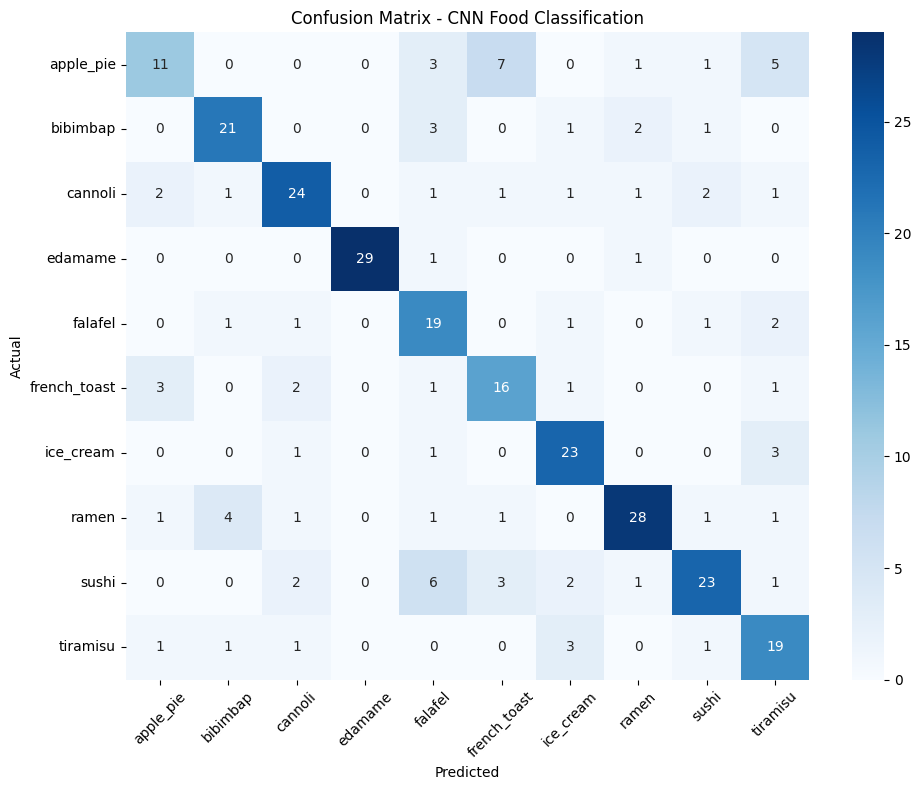

In [22]:
y_pred_cnn = model.predict(X_test_cnn)
y_pred_classes = np.argmax(y_pred_cnn, axis=1)
y_true_classes = np.argmax(y_test_cnn, axis=1)

final_accuracy = accuracy_score(y_true_classes, y_pred_classes)
print(f"✅ Final CNN Accuracy: {final_accuracy*100:.2f}%")
print(f"\n📊 Classification Report:")
print(classification_report(y_true_classes, y_pred_classes,
                            target_names=label_encoder_cnn.classes_))

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true_classes, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder_cnn.classes_,
            yticklabels=label_encoder_cnn.classes_)
plt.title('Confusion Matrix - CNN Food Classification')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('cnn_confusion_matrix.png')
plt.show()

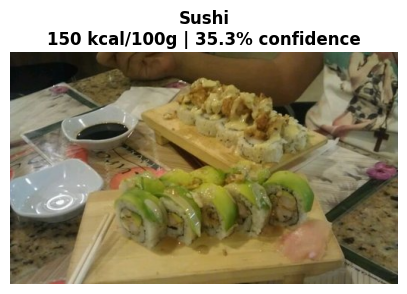

🍽️ Food Identified: Sushi
📊 Confidence: 35.3%
🔥 Calories: 150 kcal per 100g serving


In [23]:
def predict_food_and_calories(image_path):
    img = cv2.imread(image_path)
    img_display = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (96, 96))
    img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
    img_array = np.expand_dims(img_rgb.astype('float32'), axis=0)
    img_preprocessed = preprocess_input(img_array)

    prediction = model.predict(img_preprocessed, verbose=0)
    predicted_class = np.argmax(prediction)
    confidence = prediction[0][predicted_class] * 100

    food_name = label_encoder_cnn.classes_[predicted_class]
    calories = calorie_info[food_name]

    plt.figure(figsize=(5, 5))
    plt.imshow(img_display)
    plt.title(f'{food_name.replace("_", " ").title()}\n{calories} kcal/100g | {confidence:.1f}% confidence',
              fontsize=12, fontweight='bold')
    plt.axis('off')
    plt.show()

    print(f"🍽️ Food Identified: {food_name.replace('_', ' ').title()}")
    print(f"📊 Confidence: {confidence:.1f}%")
    print(f"🔥 Calories: {calories} kcal per 100g serving")

# Test with a sample image
test_food = 'data/food-101-tiny/valid/sushi'
test_image = os.path.join(test_food, os.listdir(test_food)[0])
predict_food_and_calories(test_image)

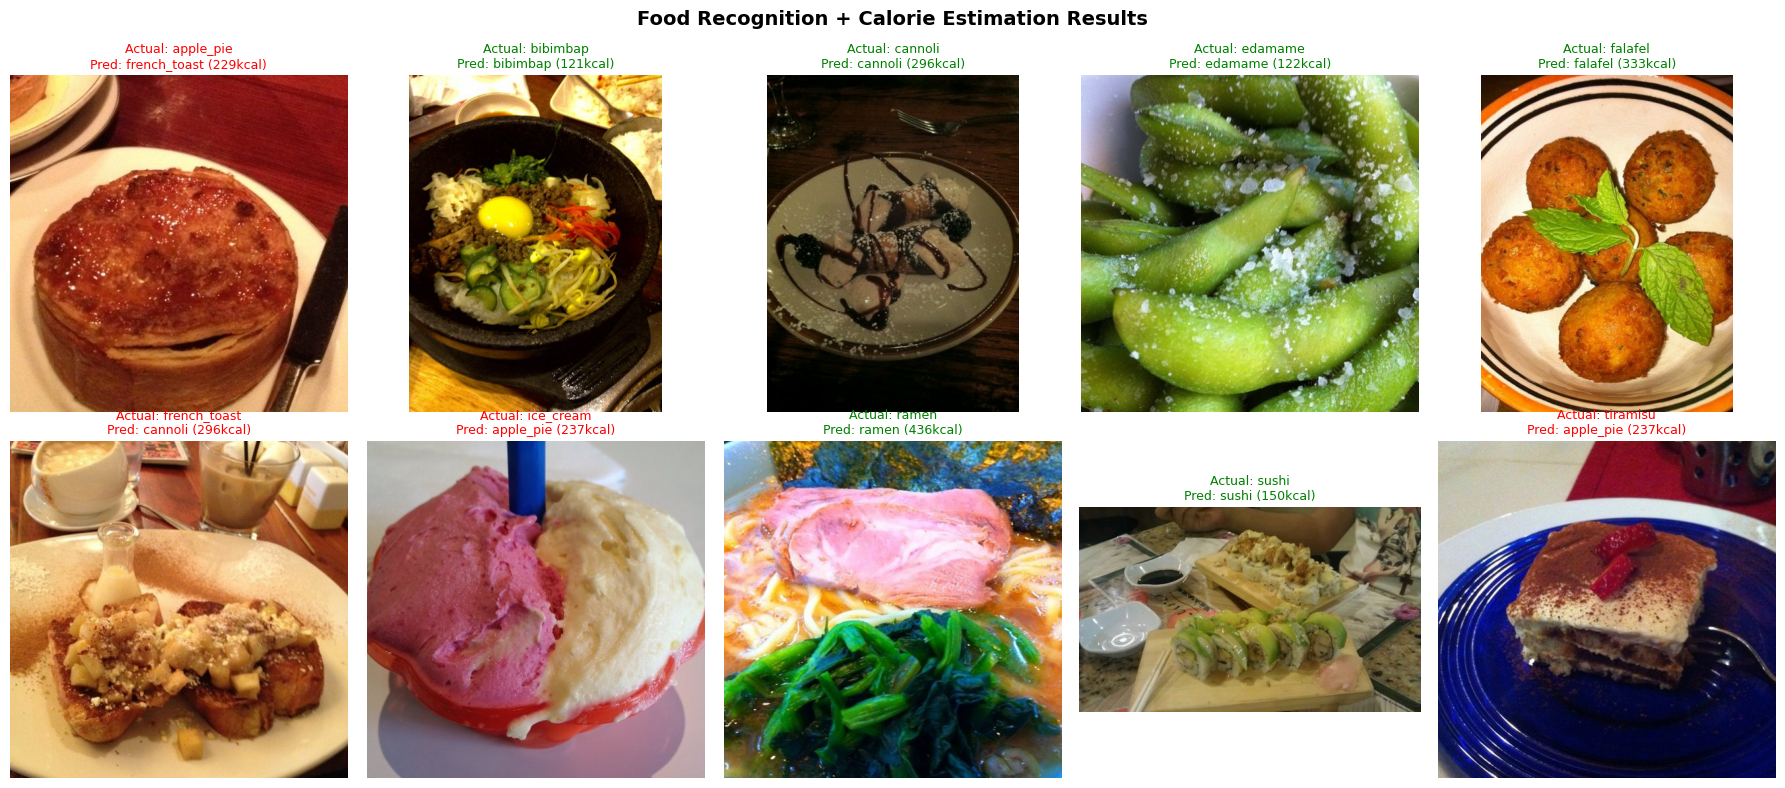

In [24]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.ravel()

valid_path = 'data/food-101-tiny/valid'
food_folders_valid = sorted(os.listdir(valid_path))

for i, food in enumerate(food_folders_valid):
    food_path = os.path.join(valid_path, food)
    img_name = os.listdir(food_path)[0]
    img_path = os.path.join(food_path, img_name)

    img = cv2.imread(img_path)
    img_display = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (96, 96))
    img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
    img_array = np.expand_dims(img_rgb.astype('float32'), axis=0)
    img_preprocessed = preprocess_input(img_array)

    prediction = model.predict(img_preprocessed, verbose=0)
    predicted_class = np.argmax(prediction)
    confidence = prediction[0][predicted_class] * 100
    predicted_food = label_encoder_cnn.classes_[predicted_class]
    calories = calorie_info[predicted_food]

    correct = predicted_food == food

    axes[i].imshow(img_display)
    axes[i].set_title(f'Actual: {food}\nPred: {predicted_food} ({calories}kcal)',
                      fontsize=9,
                      color='green' if correct else 'red')
    axes[i].axis('off')

plt.suptitle('Food Recognition + Calorie Estimation Results',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('food_predictions.png')
plt.show()

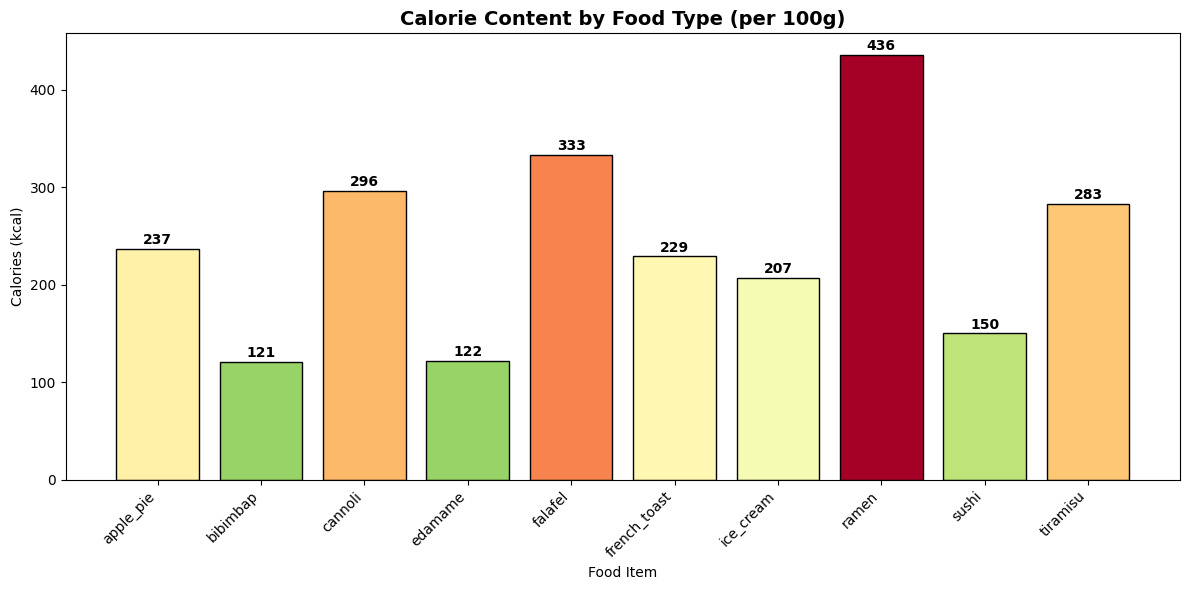

In [25]:
plt.figure(figsize=(12, 6))
foods = list(calorie_info.keys())
calories = list(calorie_info.values())

colors = plt.cm.RdYlGn_r([c/max(calories) for c in calories])
bars = plt.bar(foods, calories, color=colors, edgecolor='black')

plt.title('Calorie Content by Food Type (per 100g)', fontsize=14, fontweight='bold')
plt.xlabel('Food Item')
plt.ylabel('Calories (kcal)')
plt.xticks(rotation=45, ha='right')

for bar, cal in zip(bars, calories):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{cal}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('calorie_chart.png')
plt.show()

In [26]:
print("="*55)
print("   🍽️ FOOD RECOGNITION & CALORIE ESTIMATION SUMMARY")
print("="*55)
print(f"\n📊 Dataset:")
print(f"   Total Images   : 1500")
print(f"   Food Categories: 10")
print(f"\n🤖 Model Approach 1 (SVM + HOG + Color):")
print(f"   Accuracy       : 33.33%")
print(f"\n🤖 Model Approach 2 (CNN + Transfer Learning):")
print(f"   Architecture   : MobileNetV2")
print(f"   Accuracy       : 71.00%")
print(f"\n📈 Improvement   : +37.67% using Deep Learning!")
print(f"\n🍕 Food Categories & Calories (per 100g):")
for food, cal in calorie_info.items():
    print(f"   • {food.replace('_', ' ').title():15s}: {cal} kcal")
print("="*55)


   🍽️ FOOD RECOGNITION & CALORIE ESTIMATION SUMMARY

📊 Dataset:
   Total Images   : 1500
   Food Categories: 10

🤖 Model Approach 1 (SVM + HOG + Color):
   Accuracy       : 33.33%

🤖 Model Approach 2 (CNN + Transfer Learning):
   Architecture   : MobileNetV2
   Accuracy       : 71.00%

📈 Improvement   : +37.67% using Deep Learning!

🍕 Food Categories & Calories (per 100g):
   • Apple Pie      : 237 kcal
   • Bibimbap       : 121 kcal
   • Cannoli        : 296 kcal
   • Edamame        : 122 kcal
   • Falafel        : 333 kcal
   • French Toast   : 229 kcal
   • Ice Cream      : 207 kcal
   • Ramen          : 436 kcal
   • Sushi          : 150 kcal
   • Tiramisu       : 283 kcal
